<a href="https://colab.research.google.com/github/Rohan-1103/Data-Science/blob/main/DL/correct_xavier_weight_initializations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/ushape.csv', header = None)
df.columns=["X", "Y", "class"]

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


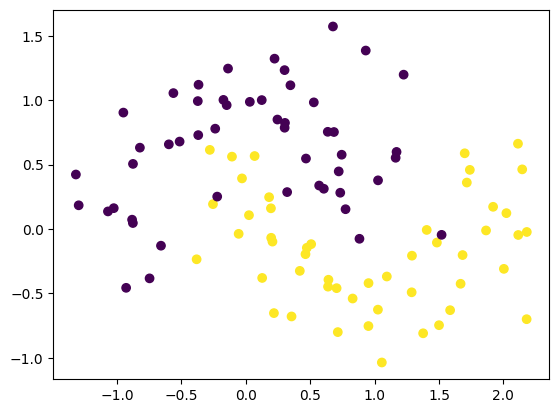

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[ 0.41983014, -0.6567929 ,  0.4867689 , -0.04905808, -0.15927869,
         -0.64158595,  0.43177384,  0.5637036 , -0.6102467 ,  0.6095838 ],
        [ 0.1795314 ,  0.01457858, -0.23686698, -0.23055676, -0.06494141,
          0.19586754,  0.08264625, -0.22543034,  0.33092362, -0.21669295]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.27249625, -0.51974463, -0.35645485, -0.15716776,  0.52990687,
          0.37790394,  0.09176642,  0.51403177, -0.31756023,  0.32326478],
        [-0.11864555,  0.01864052, -0.07095119,  0.47683632, -0.4628405 ,
          0.1532458 , -0.5307063 ,  0.43497515,  0.36019003, -0.10470837],
        [ 0.44640946, -0.16711092, -0.52003455,  0.22981459,  0.18587577,
         -0.26141334, -0.4077716 , -0.2794277 , -0.22060809,  0.3616535 ],
        [ 0.29767686, -0.11795658, -0.4459707 ,  0.03978342, -0.41758484,
         -0.16361314, -0.24219218, -0.5160123 , -0.22791404,  0.1888426 ],
        [-0.23894

In [9]:
initial_weights = model.get_weights()

### Xavier Initialization

In [10]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[ 0.27062213, -0.5967605 ,  0.43148145,  1.6878315 , -0.4540881 ,
         -0.5588715 ,  0.0118638 , -0.7094793 ,  0.62046546,  0.5184151 ],
        [-0.50008374, -0.38831064, -0.718583  ,  0.46163964, -0.12854369,
          0.928581  , -0.274338  , -0.14982133,  1.057579  , -0.4363926 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-1.74818799e-01,  2.11996675e-01, -1.53535634e-01,
         -4.10116374e-01, -1.32280856e-01,  4.78233933e-01,
          2.14238614e-01, -5.21247745e-01,  2.95658763e-02,
          2.27287427e-01],
        [-1.94605172e-01,  4.18246180e-01,  5.74048102e-01,
          7.72322893e-01, -9.03319269e-02, -2.76537061e-01,
          5.18050551e-01,  1.70074433e-01,  6.19486570e-01,
          3.59150507e-02],
        [ 4.93147135e-01,  3.31865437e-02, -6.70337826e-02,
         -1.09285988e-01, -3.68990242e-01,  6.61273450e-02,
         -1.26702651e-01,  1.87751874e-01,  4.35761452e-01,
         -1.9115863

In [13]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [14]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.3492 - loss: 0.7831 - val_accuracy: 0.6500 - val_loss: 0.7144
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5180 - loss: 0.7428 - val_accuracy: 0.7000 - val_loss: 0.6898
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5469 - loss: 0.7423 - val_accuracy: 0.7500 - val_loss: 0.6692
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5391 - loss: 0.7249 - val_accuracy: 0.7500 - val_loss: 0.6487
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5852 - loss: 0.6999 - val_accuracy: 0.7500 - val_loss: 0.6293
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5930 - loss: 0.6852 - val_accuracy: 0.7500 - val_loss: 0.6115
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6070 - loss: 0.6690 - val_accuracy: 0.7500 - val_loss: 0.5948
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5977 - loss: 0.6657 - val_accuracy: 0.8000 - val_loss

In [15]:
model.get_weights()

[array([[ 0.21716462, -0.49849927,  0.33815676,  1.6261294 , -0.4728861 ,
         -0.47748765,  0.08657371, -0.6734279 ,  0.6473124 ,  0.40294406],
        [-0.42162856, -0.27096796, -0.80844426,  0.43902695, -0.05420939,
          1.0088933 , -0.379514  , -0.11745223,  1.1801876 , -0.5574406 ]],
       dtype=float32),
 array([ 0.02551183, -0.07378061, -0.1189244 ,  0.2156209 , -0.08012143,
        -0.02832309, -0.01678163,  0.16257428, -0.13799489, -0.07898552],
       dtype=float32),
 array([[-0.06508233,  0.12901188, -0.07112505, -0.36705506, -0.0326727 ,
          0.500238  ,  0.14191855, -0.45951742, -0.00733171,  0.12444144],
        [-0.04612328,  0.3883708 ,  0.52497447,  0.8391338 , -0.0304581 ,
         -0.14876942,  0.51888794,  0.22215688,  0.61277336, -0.01576367],
        [ 0.63311976, -0.05210806,  0.00530621, -0.05625541, -0.27065662,
          0.12622805, -0.19705653,  0.2540372 ,  0.42423812, -0.29371098],
        [ 0.07800332,  0.06936929, -0.4360893 , -0.20434222, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

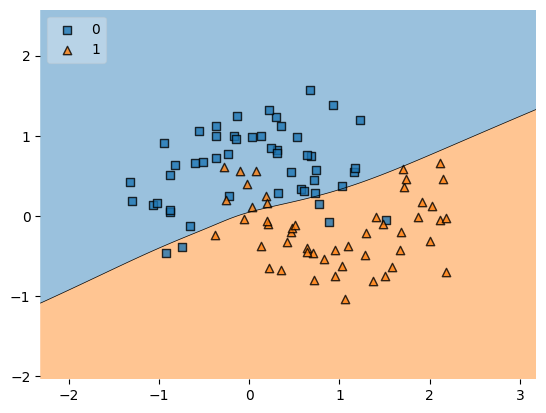

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [17]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.019985516208760382)

In [18]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.027304848050329227)